In [83]:
import torch
import os
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from PIL import Image
from torchvision.utils import save_image

In [39]:
#load image =>transform,tensor convert,load=> datasets of all images
class ImageProcessor(Dataset):

    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        self.all_img_paths = [
            os.path.join(root_dir_path, img)
            for img in os.listdir(root_dir_path)
            if img.lower().endswith(".jpg")
        ]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [40]:
root_dir_path="./archive/img_align_celeba/img_align_celeba"

transformations=transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [52]:
dataset=ImageProcessor(root_dir_path,transformations)
print(f"loaded {len(dataset)} images")

loaded 115419 images


In [53]:
dataloader=DataLoader(dataset,batch_size=128,shuffle=True)

## generator network


In [54]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [56]:
class Generator(nn.Module):
    def __init__(self,z_dim=100,img_channels=3): #3=>rgb
        super(Generator,self).__init__()


        #fully connected(dense)
        self.model=nn.Sequential(
            nn.Linear(z_dim,256), #100=>upsampling=>256
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,64*64*img_channels),
            nn.Tanh() #[-1,1]
        )

    def forward(self,z):
        img=self.model(z)
        img=img.view(img.size(0),3,64,64)
        return img

# Discriminator Network

In [62]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3): #3=>rgb
        super(Discriminator,self).__init__()


        #fully connected(dense)
        self.model=nn.Sequential(
            nn.Flatten(),#4d tensor=> 1d
            

            
            nn.Linear(img_channels*64*64,1024), #100=>upsampling=>256
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(256,1),
            nn.Sigmoid() #probability of being real or fake
        )

    def forward(self,img):
        return self.model(img)
        

In [63]:
GAN_loss=nn.BCELoss()

generator=Generator()
g_optimizer=optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))

discriminator=Discriminator()
d_optimizer=optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [64]:
# device

import torch

if torch.backends.mps.is_available():
    device=torch.device("mps")
elif torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

print(f"device is {device}")

device is mps


In [65]:
generator=generator.to(device)
discriminator=discriminator.to(device)

# Training the GAN

In [72]:
def train(generator,discriminator,dataloader,epochs=10):
    for epoch in range(epochs):
        for i,imgs in enumerate(dataloader):
            real_imgs=imgs.to(device)
            batch_size=real_imgs.size(0)

            #create real imgs labels & fake imgs labels
            real_labels=torch.ones(batch_size,1).to(device) #[1,1,1...]
            fake_labels=torch.zeros(batch_size,1).to(device)#[0,0,0,0..]

            #train the discriminator
            d_optimizer.zero_grad()

            fake_imgs=generator(torch.randn(batch_size,100).to(device))
            real_loss=GAN_loss(discriminator(real_imgs),real_labels)
            fake_loss=GAN_loss(discriminator(fake_imgs.detach()),fake_labels)

            d_loss=(fake_loss+real_loss)/2

            d_loss.backward()
            d_optimizer.step()

            #train the generator
            g_optimizer.zero_grad()

            g_loss=GAN_loss(discriminator(fake_imgs),real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i%50==0:
                print(f"for epoch :{epoch+1}/{epochs} batch : {i+1}... G-loss: {g_loss}.. and D-loss :{d_loss}...")

        #saved generated imgs for each epoch
        saved_generated_imges(generator,epoch,device)

In [79]:
import matplotlib.pyplot as plt
import torchvision

def saved_generated_imges(generator,epoch,device,num_imges=8):
    z=torch.randn(num_imges,100).to(device)
    generated_imgs=generator(z).detach().cpu()

    grid=torchvision.utils.make_grid(generated_imgs,nrow=4,normalize=True)

    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch :1/10 batch : 1... G-loss: 1.9594018459320068.. and D-loss :0.33904337882995605...
for epoch :1/10 batch : 51... G-loss: 2.380496025085449.. and D-loss :0.36383193731307983...
for epoch :1/10 batch : 101... G-loss: 1.6314959526062012.. and D-loss :0.35075539350509644...
for epoch :1/10 batch : 151... G-loss: 2.492372751235962.. and D-loss :0.3711959719657898...
for epoch :1/10 batch : 201... G-loss: 2.112133026123047.. and D-loss :0.2981835901737213...
for epoch :1/10 batch : 251... G-loss: 2.0385329723358154.. and D-loss :0.370728999376297...
for epoch :1/10 batch : 301... G-loss: 2.081798553466797.. and D-loss :0.34758853912353516...
for epoch :1/10 batch : 351... G-loss: 2.606924057006836.. and D-loss :0.37099069356918335...
for epoch :1/10 batch : 401... G-loss: 1.7194228172302246.. and D-loss :0.47753772139549255...
for epoch :1/10 batch : 451... G-loss: 2.3452510833740234.. and D-loss :0.3598828911781311...
for epoch :1/10 batch : 501... G-loss: 2.243307113647461.. and 

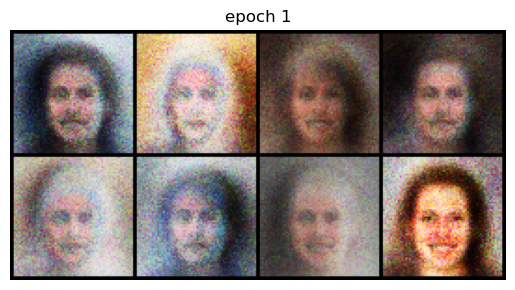

for epoch :2/10 batch : 1... G-loss: 2.0034968852996826.. and D-loss :0.3135952651500702...
for epoch :2/10 batch : 51... G-loss: 2.4984683990478516.. and D-loss :0.43383872509002686...
for epoch :2/10 batch : 101... G-loss: 1.8134230375289917.. and D-loss :0.37761616706848145...
for epoch :2/10 batch : 151... G-loss: 2.5440785884857178.. and D-loss :0.3594931364059448...
for epoch :2/10 batch : 201... G-loss: 1.4641773700714111.. and D-loss :0.4593876004219055...
for epoch :2/10 batch : 251... G-loss: 1.6995491981506348.. and D-loss :0.5377748012542725...
for epoch :2/10 batch : 301... G-loss: 1.8898377418518066.. and D-loss :0.43004655838012695...
for epoch :2/10 batch : 351... G-loss: 2.1239147186279297.. and D-loss :0.4111054837703705...
for epoch :2/10 batch : 401... G-loss: 2.069305419921875.. and D-loss :0.41097843647003174...
for epoch :2/10 batch : 451... G-loss: 1.919503092765808.. and D-loss :0.3380115330219269...
for epoch :2/10 batch : 501... G-loss: 1.5824579000473022.. a

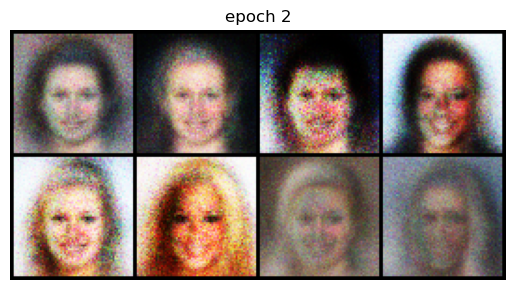

for epoch :3/10 batch : 1... G-loss: 2.120248317718506.. and D-loss :0.49304336309432983...
for epoch :3/10 batch : 51... G-loss: 2.103950023651123.. and D-loss :0.4165669083595276...
for epoch :3/10 batch : 101... G-loss: 2.1097283363342285.. and D-loss :0.45537257194519043...
for epoch :3/10 batch : 151... G-loss: 1.973966121673584.. and D-loss :0.4319990873336792...
for epoch :3/10 batch : 201... G-loss: 1.9079517126083374.. and D-loss :0.4926881790161133...
for epoch :3/10 batch : 251... G-loss: 2.0119779109954834.. and D-loss :0.48437759280204773...
for epoch :3/10 batch : 301... G-loss: 1.6933163404464722.. and D-loss :0.4114190340042114...
for epoch :3/10 batch : 351... G-loss: 1.8475127220153809.. and D-loss :0.4677235782146454...
for epoch :3/10 batch : 401... G-loss: 1.454579472541809.. and D-loss :0.42090198397636414...
for epoch :3/10 batch : 451... G-loss: 2.097446918487549.. and D-loss :0.40778201818466187...
for epoch :3/10 batch : 501... G-loss: 2.457496166229248.. and 

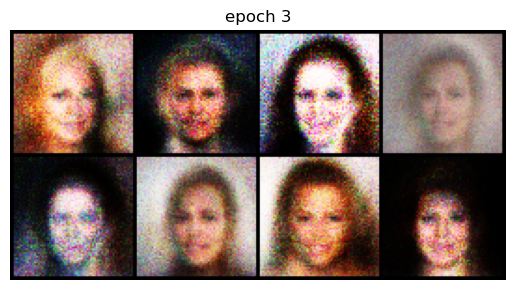

for epoch :4/10 batch : 1... G-loss: 1.6741528511047363.. and D-loss :0.48564037680625916...
for epoch :4/10 batch : 51... G-loss: 1.7833588123321533.. and D-loss :0.45240819454193115...
for epoch :4/10 batch : 101... G-loss: 1.8167521953582764.. and D-loss :0.5107182264328003...
for epoch :4/10 batch : 151... G-loss: 2.0345232486724854.. and D-loss :0.6040822267532349...
for epoch :4/10 batch : 201... G-loss: 1.6644450426101685.. and D-loss :0.4713796377182007...
for epoch :4/10 batch : 251... G-loss: 2.3682007789611816.. and D-loss :0.5838227272033691...
for epoch :4/10 batch : 301... G-loss: 1.727731466293335.. and D-loss :0.4585280418395996...
for epoch :4/10 batch : 351... G-loss: 1.8240909576416016.. and D-loss :0.5280218720436096...
for epoch :4/10 batch : 401... G-loss: 2.1251533031463623.. and D-loss :0.4613133370876312...
for epoch :4/10 batch : 451... G-loss: 1.8469266891479492.. and D-loss :0.48132771253585815...
for epoch :4/10 batch : 501... G-loss: 1.836608648300171.. an

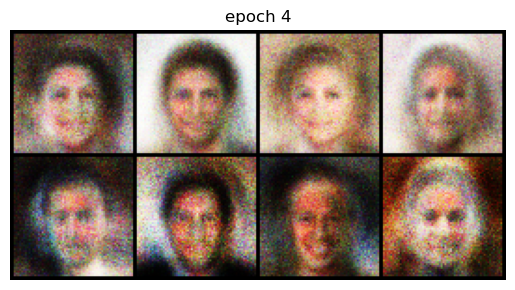

for epoch :5/10 batch : 1... G-loss: 2.015301465988159.. and D-loss :0.5121479034423828...
for epoch :5/10 batch : 51... G-loss: 2.2214741706848145.. and D-loss :0.586286187171936...
for epoch :5/10 batch : 101... G-loss: 1.7625422477722168.. and D-loss :0.55460524559021...
for epoch :5/10 batch : 151... G-loss: 1.9385945796966553.. and D-loss :0.49421703815460205...
for epoch :5/10 batch : 201... G-loss: 2.2230606079101562.. and D-loss :0.3773565888404846...
for epoch :5/10 batch : 251... G-loss: 1.9599446058273315.. and D-loss :0.48041531443595886...
for epoch :5/10 batch : 301... G-loss: 1.7689731121063232.. and D-loss :0.47198155522346497...
for epoch :5/10 batch : 351... G-loss: 1.7150826454162598.. and D-loss :0.5214911699295044...
for epoch :5/10 batch : 401... G-loss: 1.6620423793792725.. and D-loss :0.4744960069656372...
for epoch :5/10 batch : 451... G-loss: 1.9949462413787842.. and D-loss :0.4555397629737854...
for epoch :5/10 batch : 501... G-loss: 2.2878456115722656.. and 

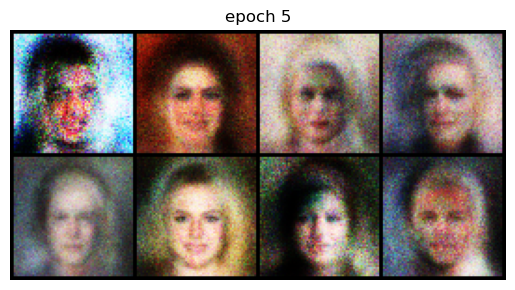

for epoch :6/10 batch : 1... G-loss: 1.7647583484649658.. and D-loss :0.5066161155700684...
for epoch :6/10 batch : 51... G-loss: 1.22517728805542.. and D-loss :0.476699560880661...
for epoch :6/10 batch : 101... G-loss: 1.771187663078308.. and D-loss :0.5560213923454285...
for epoch :6/10 batch : 151... G-loss: 1.9389382600784302.. and D-loss :0.4784187972545624...
for epoch :6/10 batch : 201... G-loss: 1.6316702365875244.. and D-loss :0.5009859800338745...
for epoch :6/10 batch : 251... G-loss: 1.8666861057281494.. and D-loss :0.4479983448982239...
for epoch :6/10 batch : 301... G-loss: 1.484121561050415.. and D-loss :0.5062072277069092...
for epoch :6/10 batch : 351... G-loss: 1.697880744934082.. and D-loss :0.4648708999156952...
for epoch :6/10 batch : 401... G-loss: 2.4388813972473145.. and D-loss :0.5391309857368469...
for epoch :6/10 batch : 451... G-loss: 1.8188519477844238.. and D-loss :0.5286836624145508...
for epoch :6/10 batch : 501... G-loss: 1.794379711151123.. and D-loss

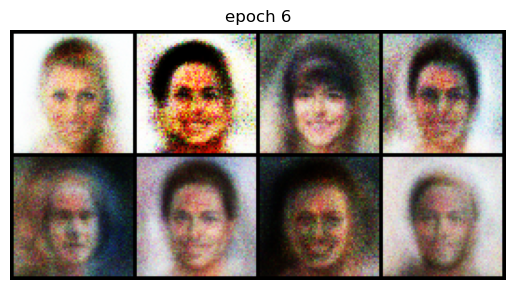

for epoch :7/10 batch : 1... G-loss: 1.5520191192626953.. and D-loss :0.5118206739425659...
for epoch :7/10 batch : 51... G-loss: 1.5387345552444458.. and D-loss :0.5521386861801147...
for epoch :7/10 batch : 101... G-loss: 1.637453556060791.. and D-loss :0.46480533480644226...
for epoch :7/10 batch : 151... G-loss: 1.8204472064971924.. and D-loss :0.4855852723121643...
for epoch :7/10 batch : 201... G-loss: 2.061497211456299.. and D-loss :0.47768130898475647...
for epoch :7/10 batch : 251... G-loss: 1.9444270133972168.. and D-loss :0.4665204882621765...
for epoch :7/10 batch : 301... G-loss: 1.9687438011169434.. and D-loss :0.5066410303115845...
for epoch :7/10 batch : 351... G-loss: 1.6215643882751465.. and D-loss :0.5771634578704834...
for epoch :7/10 batch : 401... G-loss: 1.67142915725708.. and D-loss :0.528156042098999...
for epoch :7/10 batch : 451... G-loss: 1.6353976726531982.. and D-loss :0.44563424587249756...
for epoch :7/10 batch : 501... G-loss: 1.7344048023223877.. and D

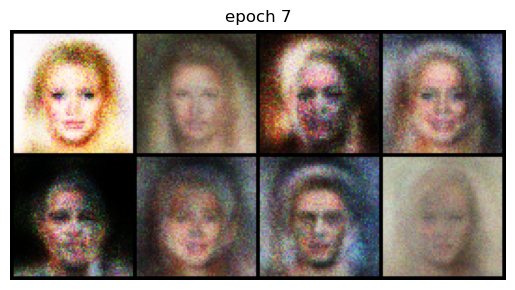

for epoch :8/10 batch : 1... G-loss: 1.4966535568237305.. and D-loss :0.48304498195648193...
for epoch :8/10 batch : 51... G-loss: 1.480607032775879.. and D-loss :0.4937101900577545...
for epoch :8/10 batch : 101... G-loss: 1.7650651931762695.. and D-loss :0.485350102186203...
for epoch :8/10 batch : 151... G-loss: 1.8999700546264648.. and D-loss :0.6058132648468018...
for epoch :8/10 batch : 201... G-loss: 1.8029429912567139.. and D-loss :0.5433933734893799...
for epoch :8/10 batch : 251... G-loss: 1.9449330568313599.. and D-loss :0.4301206171512604...
for epoch :8/10 batch : 301... G-loss: 1.9206647872924805.. and D-loss :0.4497019946575165...
for epoch :8/10 batch : 351... G-loss: 2.028534412384033.. and D-loss :0.5147972106933594...
for epoch :8/10 batch : 401... G-loss: 1.7119749784469604.. and D-loss :0.4904131293296814...
for epoch :8/10 batch : 451... G-loss: 1.6137995719909668.. and D-loss :0.5244171619415283...
for epoch :8/10 batch : 501... G-loss: 1.6537678241729736.. and D

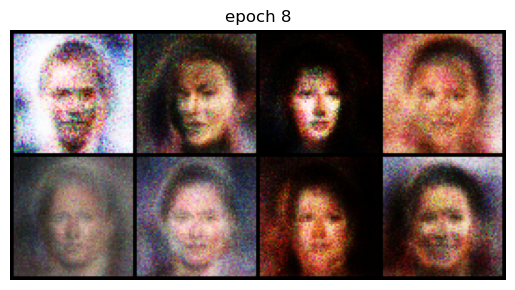

for epoch :9/10 batch : 1... G-loss: 1.5587594509124756.. and D-loss :0.4778626561164856...
for epoch :9/10 batch : 51... G-loss: 1.3369702100753784.. and D-loss :0.5379877686500549...
for epoch :9/10 batch : 101... G-loss: 1.4809050559997559.. and D-loss :0.5327828526496887...
for epoch :9/10 batch : 151... G-loss: 1.4469702243804932.. and D-loss :0.5188298225402832...
for epoch :9/10 batch : 201... G-loss: 1.3354555368423462.. and D-loss :0.49541085958480835...
for epoch :9/10 batch : 251... G-loss: 2.2109737396240234.. and D-loss :0.4900719225406647...
for epoch :9/10 batch : 301... G-loss: 1.792865514755249.. and D-loss :0.4891394078731537...
for epoch :9/10 batch : 351... G-loss: 1.4724199771881104.. and D-loss :0.5315874218940735...
for epoch :9/10 batch : 401... G-loss: 1.5332993268966675.. and D-loss :0.5782207250595093...
for epoch :9/10 batch : 451... G-loss: 1.6767442226409912.. and D-loss :0.5021021962165833...
for epoch :9/10 batch : 501... G-loss: 1.5681871175765991.. and

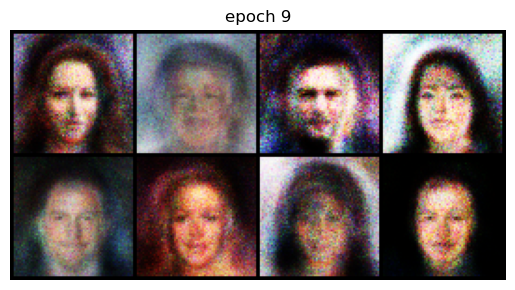

for epoch :10/10 batch : 1... G-loss: 1.690373182296753.. and D-loss :0.5755959749221802...
for epoch :10/10 batch : 51... G-loss: 1.9237475395202637.. and D-loss :0.5716843605041504...
for epoch :10/10 batch : 101... G-loss: 1.512364387512207.. and D-loss :0.48341599106788635...
for epoch :10/10 batch : 151... G-loss: 1.6240112781524658.. and D-loss :0.5006091594696045...
for epoch :10/10 batch : 201... G-loss: 1.5575509071350098.. and D-loss :0.48273539543151855...
for epoch :10/10 batch : 251... G-loss: 1.427980661392212.. and D-loss :0.5049461722373962...
for epoch :10/10 batch : 301... G-loss: 1.5506343841552734.. and D-loss :0.5763665437698364...
for epoch :10/10 batch : 351... G-loss: 1.3726409673690796.. and D-loss :0.5912772417068481...
for epoch :10/10 batch : 401... G-loss: 1.414931297302246.. and D-loss :0.46824538707733154...
for epoch :10/10 batch : 451... G-loss: 1.5612573623657227.. and D-loss :0.5740692019462585...
for epoch :10/10 batch : 501... G-loss: 1.616846561431

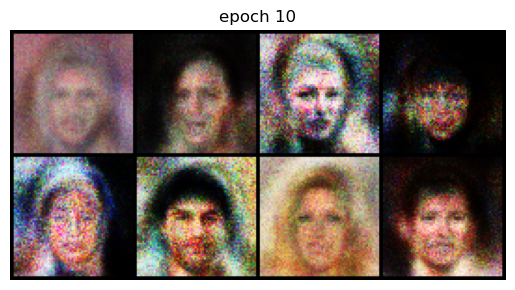

In [80]:
train(generator,discriminator,dataloader)

In [84]:
type(generator)

__main__.Generator

In [85]:
generator.eval()

with torch.no_grad():
    noise = torch.randn(25,100).to(device)
    fake_imgs = generator(noise)

save_image(
    fake_imgs,
    "samples/generated_faces.png",
    nrow=5,
    normalize=True
)

print("Saved!")

Saved!
